# 08 - Community detection

We want to see whether the station graph separates into groups that are densely connected internally but only lightly connected to the rest of the network. We use weighted Louvain for the main partition, inspect its modularity and geography, and then find the stations that carry connections across community boundaries.

The question for us is: **does the scheduled-service graph contain meaningful regional or metropolitan blocks, and which stations connect those blocks?**

Louvain is stochastic, so we do not want to treat one community count as a fixed fact about the graph. We fix the seed and resolution for a reproducible reference run, record the backend, and then vary seed and resolution to see how much the answer moves. We also compare against label propagation and separate the effect of analyzing only the largest connected component.

We rebuild the weighted undirected graph from notebook 02's `nodes.csv` and `edges.csv`. The outputs under `outputs/nb/08_community_detection/` include station assignments, a community summary, boundary-station rankings, the seed/resolution sensitivity table, a compact JSON/CSV summary, and maps of the partition, community sizes, stability, and boundary stations.

## 1. Set up paths and the runtime

We first locate the repository, switch into it, and create `outputs/nb`. The same helper can install missing packages and clone the repository in Colab. All later cells rely on the `REPO`, `DATA`, and `OUT` paths set here.

In [18]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)


Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## 2. Imports, output folders, and Louvain settings

We load the graph, table, plotting, and comparison libraries and create this notebook's `tables` and `figures` folders.

For Louvain, we use `python-louvain` if it is already installed and otherwise use NetworkX. We save that choice as `LOUVAIN_BACKEND` because different implementations can settle on different local optima. The reference run uses seed 42 and resolution 1.0. `SEED_SWEEP` changes only the random ordering, while `RESOLUTION_SWEEP` changes the preferred granularity. `RUN_LABEL_PROPAGATION` controls the separate unweighted comparison. The remaining constants only control figure size and how many rows or labels we show.

In [19]:
# --- Libraries and stage folders ------------------------------------------
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn', 'scikit-learn')

import json
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)

# Prefer python-louvain when it is already installed. It is optional: NetworkX
# provides the same algorithm, so a missing package must never trigger a slow install.
try:
    import community as community_louvain
    LOUVAIN_BACKEND = 'python-louvain'
except ImportError:
    community_louvain = None
    LOUVAIN_BACKEND = 'networkx'

PREV = OUT / '02_graph_construction'      # read-only: artifacts of notebook 02
STAGE = OUT / '08_community_detection'    # everything this notebook produces
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Tunable constants ----------------------------------------------------
LOUVAIN_SEED = 42                              # RNG seed of the reference run
LOUVAIN_RESOLUTION = 1.0                       # gamma in the modularity objective
SEED_SWEEP = [0, 1, 7, 42, 123, 2024]          # seeds tried in the stability experiment
RESOLUTION_SWEEP = [0.5, 0.8, 1.0, 1.2, 2.0]   # resolutions tried at the fixed seed
RUN_LABEL_PROPAGATION = True                   # second algorithm, used only as a cross-check
WEIGHT_ATTR = 'weight'                         # edge attribute Louvain optimises over
FIG_DPI = 150                                  # figure resolution; drop to 90 for smaller files
TOP_N = 20                                     # rows shown in every top-N table / bar chart
MAP_ALPHA = 0.6                                # point transparency on the ~30k-point maps
MAP_POINT_SIZE = 3                             # marker size on the community map
ANNOTATE_TOP = 8                               # communities labelled in place on the map

print('previous stage :', PREV)
print('this stage     :', STAGE)
print('Louvain backend:', LOUVAIN_BACKEND)
print(f'seed = {LOUVAIN_SEED}, resolution = {LOUVAIN_RESOLUTION}')


previous stage : /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction
this stage     : /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/08_community_detection
Louvain backend: networkx
seed = 42, resolution = 1.0


## 3. Set up Hebrew plotting

This matplotlib build already applies bidirectional text correctly, so we leave Hebrew strings in their normal order and make `fix_he` a no-op. We only select a Hebrew-capable font, disable confusing scientific offsets, and remove any leftover text patch that could reverse a label twice.

In [20]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We do not pre-reorder it with python-bidi because that would reverse it a second time.
# fix_he is a no-op here, and we only select a Hebrew-capable font. (If Hebrew renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()


## 4. Load the node and edge tables

We locate `nodes.csv` and `edges.csv` inside the notebook 02 output folder, read station IDs as strings, and stop with a clear error if either file is missing. We use CSV rather than a serialized graph so we can see exactly which rows and attributes are entering this analysis.

In [21]:
# --- Locate the artifacts written by notebook 02 --------------------------
def find_artifact(stage_dir, filename):
    """Return the path of `filename` under a stage folder, or None if absent."""
    if not stage_dir.is_dir():
        return None
    direct = stage_dir / filename
    if direct.exists():
        return direct
    matches = sorted(stage_dir.rglob(filename))
    return matches[0] if matches else None

nodes_path = find_artifact(PREV, 'nodes.csv')
edges_path = find_artifact(PREV, 'edges.csv')
missing = [name for name, p in [('nodes.csv', nodes_path), ('edges.csv', edges_path)] if p is None]
if missing:
    raise FileNotFoundError(
        f"{', '.join(missing)} not found under {PREV} - "
        'run notebook 02_graph_construction first; it writes nodes.csv and edges.csv.'
    )

nodes_df = pd.read_csv(nodes_path, dtype={'stop_id': str}, encoding='utf-8-sig')
edges_df = pd.read_csv(edges_path, dtype={'from_stop': str, 'to_stop': str}, encoding='utf-8-sig')
print(f'nodes: {len(nodes_df):,} rows  <-  {nodes_path}')
print(f'edges: {len(edges_df):,} rows  <-  {edges_path}')
nodes_df.head()


nodes: 30,463 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/tables/nodes.csv
edges: 51,999 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/tables/edges.csv


,stop_id,stop_name,lat,lon,region,metro,stop_use_count
0,38725,ת. רכבת יבנה מערב,31.890700,34.731191,Center,Tel Aviv,1370
1,15582,שד. הסנהדרין/שד. ירושלים,31.887865,34.734514,Center,Tel Aviv,228
2,15746,שד. ירושלים/שד. הסנהדרין,31.887569,34.733548,Center,Tel Aviv,742
3,15725,בית ספר אורמת/נחל חריף,31.894514,34.734783,Center,Tel Aviv,84
4,15416,מחלף בית רבן למזרח,31.819528,34.730697,Center,Tel Aviv,832


## 5. Rebuild the weighted undirected graph

The edge table describes consecutive stops in scheduled trips and can contain both travel directions. For community detection we collapse each unordered station pair into one edge and sum the two directional frequencies into `weight`. This makes a heavily served connection pull its endpoints together more strongly than a rare connection.

We attach name, coordinate, region, and metro attributes from the node table and convert blanks or non-finite coordinates to safe missing values. Self-loops are skipped. The printed node, edge, total-weight, and unnamed-node counts are our first check that the reconstruction is sensible.

In [22]:
# --- Rebuild the weighted undirected graph ---------------------------------
def _num(value):
    """Coerce to float; return None for blanks, NaN or non-numeric input."""
    if value is None:
        return None
    try:
        f = float(value)
    except (TypeError, ValueError):
        return None
    return None if not np.isfinite(f) else f


def _txt(value):
    """Coerce to a plain string; NaN and None become an empty string."""
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        return ''
    return str(value)


def build_undirected_graph(nodes_df, edges_df):
    """Undirected projection of the directed trip graph; opposite-direction weights summed."""
    attr = {}
    for rec in nodes_df.to_dict('records'):
        attr[str(rec.get('stop_id'))] = {
            'stop_name': _txt(rec.get('stop_name')),
            'lat': _num(rec.get('lat')),
            'lon': _num(rec.get('lon')),
            'region': _txt(rec.get('region')),
            'metro': _txt(rec.get('metro')),
        }

    weight_col = next((c for c in ('trip_frequency', 'weight', 'count')
                       if c in edges_df.columns), None)

    G = nx.Graph()
    for rec in edges_df.to_dict('records'):
        u, v = str(rec['from_stop']), str(rec['to_stop'])
        if u == v:
            continue
        w = int(rec[weight_col]) if weight_col else 1
        if G.has_edge(u, v):
            G[u][v][WEIGHT_ATTR] += w
        else:
            G.add_edge(u, v, **{WEIGHT_ATTR: w})

    default = {'stop_name': '', 'lat': None, 'lon': None, 'region': '', 'metro': ''}
    for n in G.nodes():
        G.nodes[n].update(attr.get(n, default))
    return G


G = build_undirected_graph(nodes_df, edges_df)
total_weight = sum(d[WEIGHT_ATTR] for _, _, d in G.edges(data=True))
unnamed = sum(1 for n in G.nodes() if not G.nodes[n]['stop_name'])
print(f'undirected G : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'total edge weight (trips over all segments): {total_weight:,}')
print(f'nodes with no name attribute: {unnamed:,}')


undirected G : 30,463 nodes, 51,772 edges
total edge weight (trips over all segments): 15,290,773
nodes with no name attribute: 0


## 6. Analyze the largest connected component

We sort the connected components and copy the largest one into `Gc`. Disconnected islands would each be forced into at least one separate community, which would inflate the count without helping us understand the structure of the main network.

We still keep track of every excluded station. The assignment table later marks them with community `-1`. This cell prints the component coverage and also the number of extra disconnected components, so we can see exactly how graph scope would affect a full-graph count.

In [23]:
# --- Largest connected component ------------------------------------------
components = sorted(nx.connected_components(G), key=len, reverse=True)
Gc = G.subgraph(components[0]).copy()

outside = G.number_of_nodes() - Gc.number_of_nodes()
print(f'connected components in G          : {len(components):,}')
print(f'largest component (analysed)       : {Gc.number_of_nodes():,} nodes, '
      f'{Gc.number_of_edges():,} edges '
      f'({Gc.number_of_nodes() / G.number_of_nodes():.2%} of all stations)')
print(f'stations outside it (community -1) : {outside:,}')
print(f'running on the full graph instead would add {len(components) - 1} trivial communities')


connected components in G          : 12
largest component (analysed)       : 30,237 nodes, 51,523 edges (99.26% of all stations)
stations outside it (community -1) : 226
running on the full graph instead would add 11 trivial communities


## 7. Run Louvain with an explicit configuration

Louvain greedily maximizes weighted modularity:

$$Q = \frac{1}{2m}\sum_{i,j}\left[A_{ij}-\gamma\frac{k_i k_j}{2m}\right]\delta(c_i,c_j).$$

Here `A` is the summed trip weight, `k` is weighted degree, and `gamma` is the resolution. A high value means more weight stays inside the proposed communities than we would expect from a degree-preserving random baseline.

We wrap both supported backends behind the same seed/resolution interface, score every partition with the same NetworkX modularity function, and relabel community IDs by descending size. The relabeling does not change membership; it only makes ID 0 the largest group instead of keeping arbitrary algorithm IDs. The cell then prints the reference run's backend, configuration, community count, modularity, largest group, median size, and number of groups below ten stations.

In [24]:
# --- Louvain helpers -------------------------------------------------------
def louvain_partition(graph, seed, resolution, weight=WEIGHT_ATTR):
    """One Louvain run -> {node: community_id}. Seed and resolution are always explicit."""
    if community_louvain is not None:
        return dict(community_louvain.best_partition(
            graph, weight=weight, resolution=resolution, random_state=seed))
    communities = nx.community.louvain_communities(
        graph, weight=weight, resolution=resolution, seed=seed)
    return {node: cid for cid, members in enumerate(communities) for node in members}


def groups_from_partition(partition):
    """{node: cid} -> {cid: set(nodes)}."""
    groups = defaultdict(set)
    for node, cid in partition.items():
        groups[cid].add(node)
    return groups


def partition_modularity(graph, partition, weight=WEIGHT_ATTR, resolution=1.0):
    """Newman-Girvan modularity of a partition, scored with networkx for comparability."""
    groups = groups_from_partition(partition)
    return float(nx.community.modularity(
        graph, list(groups.values()), weight=weight, resolution=resolution))


def relabel_by_size(partition):
    """Renumber communities so id 0 is the largest; ties broken deterministically."""
    groups = groups_from_partition(partition)
    order = sorted(groups.items(), key=lambda kv: (-len(kv[1]), min(str(n) for n in kv[1])))
    mapping = {old: new for new, (old, _) in enumerate(order)}
    return {node: mapping[cid] for node, cid in partition.items()}


# --- Reference run ---------------------------------------------------------
partition = relabel_by_size(louvain_partition(Gc, LOUVAIN_SEED, LOUVAIN_RESOLUTION))
modularity = partition_modularity(Gc, partition, resolution=LOUVAIN_RESOLUTION)

community_sizes = pd.Series(Counter(partition.values())).sort_values(ascending=False)
num_communities = int(community_sizes.size)

print(f'backend                : {LOUVAIN_BACKEND}')
print(f'seed / resolution      : {LOUVAIN_SEED} / {LOUVAIN_RESOLUTION}')
print(f'communities found      : {num_communities:,}')
print(f'modularity Q           : {modularity:.4f}')
print(f'largest community      : {int(community_sizes.iloc[0]):,} stations '
      f'({community_sizes.iloc[0] / Gc.number_of_nodes():.2%} of the component)')
print(f'median community size  : {community_sizes.median():.0f}')
print(f'communities with fewer than 10 stations: {int((community_sizes < 10).sum()):,}')


backend                : networkx
seed / resolution      : 42 / 1.0
communities found      : 74
modularity Q           : 0.9436
largest community      : 1,378 stations (4.56% of the component)
median community size  : 348
communities with fewer than 10 stations: 0


## 8. Measure sensitivity instead of trusting one Louvain run

We rerun Louvain in two controlled sweeps:

- change the seed while holding resolution at 1.0;
- change resolution while holding the seed at 42.

For each result we store the community count, modularity, largest size, number of groups below ten stations, and adjusted Rand index (ARI) against the reference partition. ARI compares station pairs and ignores arbitrary community IDs: 1 means the memberships match exactly and 0 is chance-level agreement.

This is the part that tells us what is reproducible. If counts move but modularity and ARI remain high, the broad partition is similar even though boundary groups merge or split. Resolution is a deliberate modeling choice, so we expect it to change the number more strongly. Modularity values calculated at different resolutions use different objectives and should not be compared as if they were scores from one fixed test.

In [25]:
# --- Seed sweep and resolution sweep ---------------------------------------
from sklearn.metrics import adjusted_rand_score

node_order = list(Gc.nodes())
base_labels = [partition[n] for n in node_order]


def stability_row(experiment, seed, resolution):
    """Run Louvain once and describe the result relative to the reference partition."""
    p = louvain_partition(Gc, seed, resolution)
    sizes = Counter(p.values())
    return {
        'experiment': experiment,
        'seed': seed,
        'resolution': resolution,
        'num_communities': len(sizes),
        'modularity': round(partition_modularity(Gc, p, resolution=resolution), 4),
        'largest_community': max(sizes.values()),
        'communities_under_10': sum(1 for s in sizes.values() if s < 10),
        'ari_vs_reference': round(
            float(adjusted_rand_score(base_labels, [p[n] for n in node_order])), 4),
    }


stability = pd.DataFrame(
    [stability_row('seed sweep', s, LOUVAIN_RESOLUTION) for s in SEED_SWEEP]
    + [stability_row('resolution sweep', LOUVAIN_SEED, r) for r in RESOLUTION_SWEEP]
)
stability.to_csv(TABLES / 'louvain_stability.csv', index=False, encoding='utf-8-sig')

seed_runs = stability[stability['experiment'] == 'seed sweep']
spread = int(seed_runs['num_communities'].max() - seed_runs['num_communities'].min())
print('across seeds, at the fixed resolution:')
print(f"  communities : {int(seed_runs['num_communities'].min())} to "
      f"{int(seed_runs['num_communities'].max())}  (spread {spread})")
print(f"  modularity  : {seed_runs['modularity'].min():.4f} to {seed_runs['modularity'].max():.4f}")
print(f"  ARI vs reference : {seed_runs['ari_vs_reference'].min():.3f} to "
      f"{seed_runs['ari_vs_reference'].max():.3f}")
stability


across seeds, at the fixed resolution:
  communities : 73 to 83  (spread 10)
  modularity  : 0.9436 to 0.9440
  ARI vs reference : 0.783 to 1.000


,experiment,seed,resolution,num_communities,modularity,largest_community,communities_under_10,ari_vs_reference
0,seed sweep,0,1.0,73,0.9440,1381,0,0.7828
1,seed sweep,1,1.0,83,0.9437,1257,0,0.8548
2,seed sweep,7,1.0,79,0.9439,1269,0,0.8450
3,seed sweep,42,1.0,74,0.9436,1378,0,1.0000
4,seed sweep,123,1.0,73,0.9438,1277,0,0.8530
5,seed sweep,2024,1.0,79,0.9439,1357,0,0.8142
6,resolution sweep,42,0.5,54,0.9587,1606,0,0.6713
7,resolution sweep,42,0.8,70,0.9496,1434,0,0.8185
8,resolution sweep,42,1.0,74,0.9436,1378,0,1.0000
9,resolution sweep,42,1.2,81,0.9398,1015,0,0.8556


### 8b. Plot the sensitivity runs

The left panel puts community count across seeds next to the modularity printed over each bar. The right panel shows how count changes with resolution and places the corresponding modularity on a second axis. Dashed lines mark the reference configuration. We use this figure to see whether randomness mainly changes the bookkeeping or whether it changes the partition substantially.

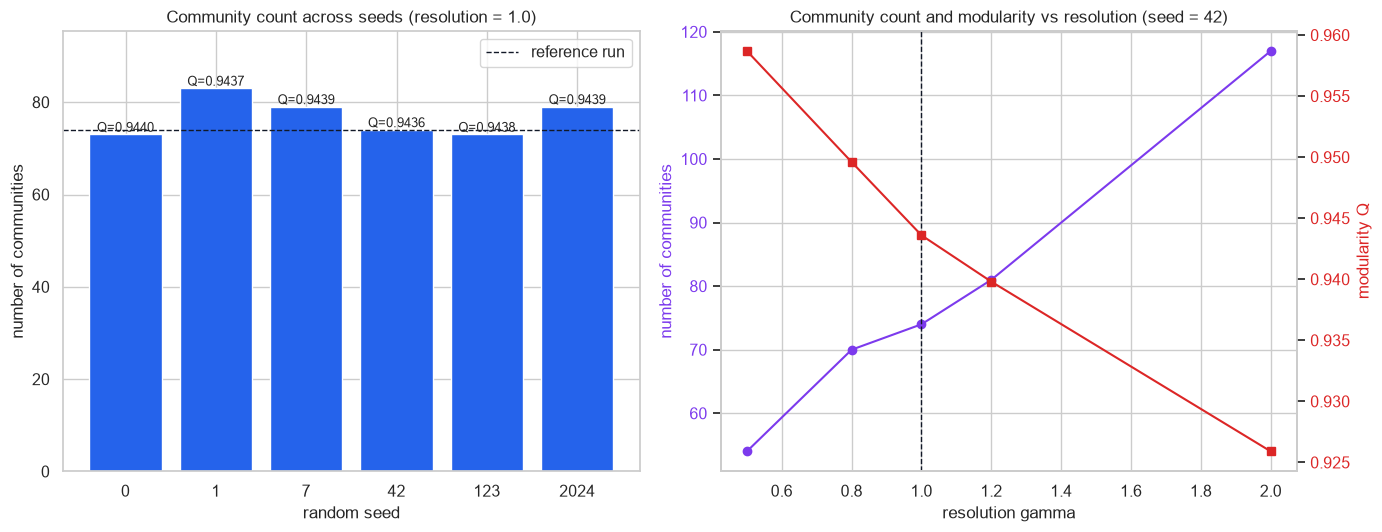

In [26]:
# --- figures/louvain_stability.png -----------------------------------------
seed_df = stability[stability['experiment'] == 'seed sweep'].sort_values('seed')
res_df = stability[stability['experiment'] == 'resolution sweep'].sort_values('resolution')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

bars = axes[0].bar(seed_df['seed'].astype(str), seed_df['num_communities'], color='#2563eb')
for bar, q in zip(bars, seed_df['modularity']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f'Q={q:.4f}', ha='center', va='bottom', fontsize=9)
axes[0].axhline(num_communities, color='#111827', linestyle='--', linewidth=1,
                label='reference run')
axes[0].set_xlabel('random seed')
axes[0].set_ylabel('number of communities')
axes[0].set_title(f'Community count across seeds (resolution = {LOUVAIN_RESOLUTION})')
axes[0].margins(y=0.15)
axes[0].legend()

axes[1].plot(res_df['resolution'], res_df['num_communities'], marker='o', color='#7c3aed')
axes[1].set_xlabel('resolution gamma')
axes[1].set_ylabel('number of communities', color='#7c3aed')
axes[1].tick_params(axis='y', labelcolor='#7c3aed')
axes[1].axvline(LOUVAIN_RESOLUTION, color='#111827', linestyle='--', linewidth=1)
twin = axes[1].twinx()
twin.plot(res_df['resolution'], res_df['modularity'], marker='s', color='#dc2626')
twin.set_ylabel('modularity Q', color='#dc2626')
twin.tick_params(axis='y', labelcolor='#dc2626')
twin.grid(False)
axes[1].set_title(f'Community count and modularity vs resolution (seed = {LOUVAIN_SEED})')

plt.tight_layout()
plt.savefig(FIGURES / 'louvain_stability.png', dpi=FIG_DPI)
plt.show()


## 9. Compare with label propagation

We run NetworkX label propagation as a deliberately different check. It updates labels from neighboring nodes, ignores edge weights, and does not optimize the Louvain objective. We relabel its groups by size, score it with the same modularity calculation, and compute ARI against Louvain.

Agreement would strengthen the case that both methods see the same blocks. Disagreement is also useful: it warns us that community granularity depends heavily on the algorithm and that we should not present a single count as uniquely correct.

In [27]:
# --- Label propagation (unweighted, cross-check only) ----------------------
if RUN_LABEL_PROPAGATION:
    lp_communities = list(nx.community.label_propagation_communities(Gc))
    partition_lp = relabel_by_size(
        {node: cid for cid, members in enumerate(lp_communities) for node in members})
    modularity_lp = partition_modularity(Gc, partition_lp, resolution=LOUVAIN_RESOLUTION)
    lp_sizes = pd.Series(Counter(partition_lp.values())).sort_values(ascending=False)
    ari_lp = float(adjusted_rand_score(base_labels, [partition_lp[n] for n in node_order]))
    print(f'label propagation communities : {int(lp_sizes.size):,}')
    print(f'label propagation modularity  : {modularity_lp:.4f}   (Louvain: {modularity:.4f})')
    print(f'largest community             : {int(lp_sizes.iloc[0]):,} stations')
    print(f'agreement with Louvain (ARI)  : {ari_lp:.3f}')
else:
    partition_lp, modularity_lp, ari_lp = {}, None, None
    print('label propagation skipped (RUN_LABEL_PROPAGATION = False)')


label propagation communities : 8,035
label propagation modularity  : 0.5469   (Louvain: 0.9436)
largest community             : 113 stations
agreement with Louvain (ARI)  : 0.019


## 10. Save one assignment row per station

We build `community_assignments.csv` for every node in the full graph. Each row keeps the station identity, geography, degree, Louvain community, and label-propagation community. Stations outside the analyzed component receive `-1`, which is a clear missing-assignment marker rather than a real group. Keeping them in the file makes later joins retain the complete station set.

In [28]:
# --- tables/community_assignments.csv --------------------------------------
assign_df = pd.DataFrame([{
    'stop_id': n,
    'stop_name': G.nodes[n]['stop_name'],
    'lat': G.nodes[n]['lat'],
    'lon': G.nodes[n]['lon'],
    'region': G.nodes[n]['region'],
    'metro': G.nodes[n]['metro'],
    'degree': G.degree(n),
    'community_louvain': partition.get(n, -1),
    'community_lp': partition_lp.get(n, -1),
} for n in G.nodes()])
assign_df = assign_df.sort_values(['community_louvain', 'degree'],
                                  ascending=[True, False]).reset_index(drop=True)
assign_df.to_csv(TABLES / 'community_assignments.csv', index=False, encoding='utf-8-sig')

print(f"saved {TABLES / 'community_assignments.csv'}  ({len(assign_df):,} rows)")
print(f"unassigned stations (community -1): {int((assign_df['community_louvain'] == -1).sum()):,}")
assign_df.head(10)


saved /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/08_community_detection/tables/community_assignments.csv  (30,463 rows)
unassigned stations (community -1): 226


,stop_id,stop_name,lat,lon,region,metro,degree,community_louvain,community_lp
0,37338,לוד,31.947694,34.879159,Center,Tel Aviv,8,-1,-1
1,37292,תל אביב ההגנה,32.053978,34.784839,Center,Tel Aviv,8,-1,-1
2,37362,הרצליה,32.163558,34.817406,Center,Tel Aviv,8,-1,-1
3,37380,חיפה מרכז,32.822306,34.997177,North,Haifa,7,-1,-1
4,37372,בנימינה,32.514386,34.949573,North,Periphery,6,-1,-1
5,37376,חוף הכרמל,32.793600,34.957404,North,Haifa,6,-1,-1
6,41293,קרית מוצקין,32.833133,35.070030,North,Haifa,6,-1,-1
7,37314,באר שבע צפון,31.262089,34.809287,South,Beer Sheva,5,-1,-1
8,37368,חדרה מערב,32.438199,34.899321,Center,Periphery,5,-1,-1
9,37316,קרית גת,31.603526,34.777955,Center,Periphery,4,-1,-1


## 11. Describe the communities from their members

For every Louvain community we calculate size, internal and external edges and weights, boundary-station count, coordinate centroid, dominant region and metro, and the highest-weighted-degree hub. We count edge totals in one pass over `Gc` so each edge is handled consistently.

`external_weight_ratio` is our quick measure of how much a community leaks into the rest of the graph. We derive the text label from the modal metro and region instead of assigning meaning to the numeric ID. The dominant shares stay in the table because a short label can hide a geographically mixed community.

In [29]:
# --- tables/community_summary.csv ------------------------------------------
groups = groups_from_partition(partition)

internal_edges = Counter(); internal_weight = Counter()
external_edges = Counter(); external_weight = Counter()
boundary_nodes = defaultdict(set)

for u, v, data in Gc.edges(data=True):
    cu, cv = partition[u], partition[v]
    w = data.get(WEIGHT_ATTR, 1)
    if cu == cv:
        internal_edges[cu] += 1
        internal_weight[cu] += w
    else:
        for c in (cu, cv):
            external_edges[c] += 1
            external_weight[c] += w
        boundary_nodes[cu].add(u)
        boundary_nodes[cv].add(v)

weighted_degree = dict(Gc.degree(weight=WEIGHT_ATTR))


def _mode(values):
    """Most common non-empty value and its share; ('', 0.0) when nothing is present."""
    counts = Counter(v for v in values if v)
    if not counts:
        return '', 0.0
    value, count = counts.most_common(1)[0]
    return value, round(count / len(values), 4)


def _label(metro, region):
    """Derived, data-driven community label: modal metro joined with modal region."""
    parts = [p for p in (metro, region) if p]
    return ' / '.join(dict.fromkeys(parts)) if parts else 'unlabelled'


rows = []
for cid, members in sorted(groups.items(), key=lambda kv: kv[0]):
    members = sorted(members)
    lats = [G.nodes[n]['lat'] for n in members if G.nodes[n]['lat'] is not None]
    lons = [G.nodes[n]['lon'] for n in members if G.nodes[n]['lon'] is not None]
    metro, metro_share = _mode([G.nodes[n]['metro'] for n in members])
    region, region_share = _mode([G.nodes[n]['region'] for n in members])
    hub = max(members, key=lambda n: (weighted_degree.get(n, 0), Gc.degree(n)))
    iw, ew = int(internal_weight[cid]), int(external_weight[cid])
    rows.append({
        'community_id': cid,
        'label': _label(metro, region),
        'size': len(members),
        'share_of_component': round(len(members) / Gc.number_of_nodes(), 5),
        'internal_edges': int(internal_edges[cid]),
        'external_edges': int(external_edges[cid]),
        'internal_weight': iw,
        'external_weight': ew,
        'external_weight_ratio': round(ew / (iw + ew), 4) if (iw + ew) else None,
        'boundary_stations': len(boundary_nodes[cid]),
        'boundary_share': round(len(boundary_nodes[cid]) / len(members), 4),
        'centroid_lat': round(float(np.mean(lats)), 4) if lats else None,
        'centroid_lon': round(float(np.mean(lons)), 4) if lons else None,
        'dominant_region': region,
        'dominant_region_share': region_share,
        'dominant_metro': metro,
        'dominant_metro_share': metro_share,
        'hub_stop_id': hub,
        'hub_stop_name': G.nodes[hub]['stop_name'],
    })

summary_df = pd.DataFrame(rows).sort_values('size', ascending=False).reset_index(drop=True)
summary_df.to_csv(TABLES / 'community_summary.csv', index=False, encoding='utf-8-sig')

print(f"saved {TABLES / 'community_summary.csv'}  ({len(summary_df):,} communities)")
print('communities per dominant metropolitan area (labels are derived, not hard-coded):')
print(summary_df['dominant_metro'].value_counts().to_string())
summary_df.head(TOP_N)[['community_id', 'label', 'size', 'internal_edges', 'external_edges',
                        'external_weight_ratio', 'dominant_metro_share', 'hub_stop_name']]


saved /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/08_community_detection/tables/community_summary.csv  (74 communities)
communities per dominant metropolitan area (labels are derived, not hard-coded):
dominant_metro
Periphery     29
Tel Aviv      19
Jerusalem     12
Haifa         11
Beer Sheva     3


,community_id,label,size,internal_edges,external_edges,external_weight_ratio,dominant_metro_share,hub_stop_name
0,0,Beer Sheva / South,1378,2040,199,0.0184,0.9419,דואר/יצחק רגר
1,1,Periphery / North,847,1331,69,0.0287,1.0000,ת. מרכזית ק''ש/הורדה
2,2,Periphery / North,839,1244,41,0.0154,0.9297,הרב קוק/ז'בוטינסקי
3,3,Periphery / North,822,1206,110,0.0273,0.9720,היכל התרבות/חטיבה תש''ע
4,4,Tel Aviv / Center,821,1304,179,0.0204,0.7272,הרצל/עולי הגרדום
5,5,Periphery / North,779,1152,147,0.0664,0.7253,סח'נין עיריה
6,6,Periphery / Center,767,1292,247,0.0625,0.9439,מלכי ישראל/יציאה צפונית
7,7,Periphery / Center,736,1219,212,0.0382,0.9728,המשנה
8,8,Periphery / North,735,1140,50,0.0191,0.9973,מרכז רסקו
9,9,Tel Aviv / Center,730,1216,230,0.0872,1.0000,דרך בר לב/שד' ששת הימים


## 12. Rank stations that cross community boundaries

We call a station a boundary station when at least one neighbor belongs to another Louvain community. This is not the same as a graph-theory bridge: removing a boundary station does not necessarily disconnect the network, but it does sit on service links between clusters.

For each one we count distinct neighboring communities, crossing edges, crossing weight, total degree, weighted degree, and the share of its weighted degree that crosses a boundary. We rank first by the number of communities touched and then by crossing weight. We also calculate the network-wide share of edges and scheduled-trip weight that cross community boundaries.

In [30]:
# --- tables/inter_community_bridges.csv ------------------------------------
label_of = dict(zip(summary_df['community_id'], summary_df['label']))

bridge_rows = []
for node in Gc.nodes():
    own = partition[node]
    other_comms = set()
    crossing_edges = 0
    crossing_weight = 0
    for nb in Gc.neighbors(node):
        cid = partition[nb]
        if cid != own:
            other_comms.add(cid)
            crossing_edges += 1
            crossing_weight += Gc[node][nb].get(WEIGHT_ATTR, 1)
    if not other_comms:
        continue
    wdeg = weighted_degree.get(node, 0)
    bridge_rows.append({
        'stop_id': node,
        'stop_name': G.nodes[node]['stop_name'],
        'own_community': own,
        'own_community_label': label_of.get(own, ''),
        'connected_communities': len(other_comms),
        'crossing_edges': crossing_edges,
        'crossing_weight': int(crossing_weight),
        'degree': Gc.degree(node),
        'weighted_degree': int(wdeg),
        'crossing_weight_share': round(crossing_weight / wdeg, 4) if wdeg else None,
        'lat': G.nodes[node]['lat'],
        'lon': G.nodes[node]['lon'],
        'region': G.nodes[node]['region'],
        'metro': G.nodes[node]['metro'],
    })

bridges_df = (pd.DataFrame(bridge_rows)
              .sort_values(['connected_communities', 'crossing_weight'], ascending=False)
              .reset_index(drop=True))
bridges_df.to_csv(TABLES / 'inter_community_bridges.csv', index=False, encoding='utf-8-sig')

cross_edges = sum(1 for u, v in Gc.edges() if partition[u] != partition[v])
cross_weight = sum(d.get(WEIGHT_ATTR, 1) for u, v, d in Gc.edges(data=True)
                   if partition[u] != partition[v])
component_weight = sum(d.get(WEIGHT_ATTR, 1) for _, _, d in Gc.edges(data=True))

print(f"saved {TABLES / 'inter_community_bridges.csv'}  ({len(bridges_df):,} stations)")
print(f'boundary stations     : {len(bridges_df):,} of {Gc.number_of_nodes():,} '
      f'({len(bridges_df) / Gc.number_of_nodes():.2%} of the analysed component)')
print(f'cross-community edges : {cross_edges:,} of {Gc.number_of_edges():,} '
      f'({cross_edges / Gc.number_of_edges():.2%})')
print(f'cross-community trips : {cross_weight:,} of {component_weight:,} '
      f'({cross_weight / component_weight:.2%} of all trip weight)')
bridges_df.head(TOP_N)[['stop_id', 'stop_name', 'own_community_label', 'connected_communities',
                        'crossing_edges', 'crossing_weight', 'degree']]


saved /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/08_community_detection/tables/inter_community_bridges.csv  (3,468 stations)
boundary stations     : 3,468 of 30,237 (11.47% of the analysed component)
cross-community edges : 3,713 of 51,523 (7.21%)
cross-community trips : 490,398 of 15,202,043 (3.23% of all trip weight)


,stop_id,stop_name,own_community_label,connected_communities,crossing_edges,crossing_weight,degree
0,41133,מחלף חמד,Jerusalem,17,31,2890,62
1,41132,מחלף חמד,Jerusalem,15,23,2271,44
2,9048,בן גוריון/שערי ירושלים,Jerusalem,13,18,2163,41
3,23418,רבי יהודה הנשיא/כניסה לעיר,Tel Aviv / Center,13,19,659,24
4,9046,ויצמן/גבעת שאול,Jerusalem,12,18,3286,36
5,7444,דרך האר''י/ כביש 375,Jerusalem / Center,12,20,1956,29
6,51199,דרך האר''י/המגיד ממעזריטש,Jerusalem / Center,12,17,987,22
7,7562,שדרות בית הלל/כניסה לעיר,Tel Aviv / Center,12,22,453,29
8,25419,רבי יהודה הנשיא/חוני המעגל,Tel Aviv / Center,12,16,326,21
9,748,מחלף קסם,Tel Aviv / Center,11,18,1034,19


## 13. Check whether the partition makes geographic sense

We plot analyzed stations at their coordinates and color them by Louvain community. Stations outside the largest component stay in light gray, and the largest communities get labels at their centroids. The purpose is a visual sanity check: in a transport graph we expect mostly contiguous geographic patches, not colors scattered randomly across the country.

We cycle through several categorical palettes because there are more groups than one palette can distinguish. Color is only for seeing patch boundaries; the derived labels and exported IDs are what identify a particular community.

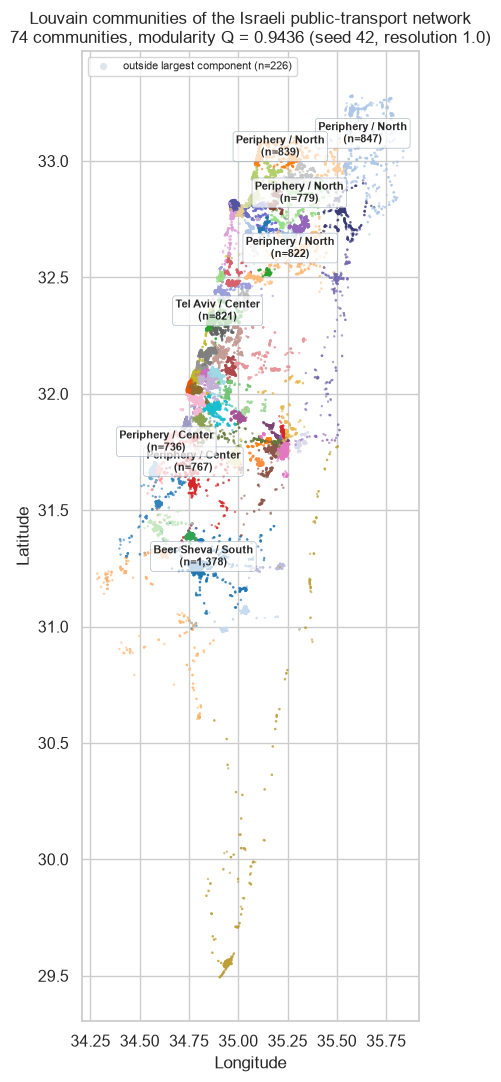

plotted 30,237 of 30,237 analysed stations (0 lack usable coordinates)


In [31]:
# --- figures/community_map_louvain.png -------------------------------------
def has_coords(node):
    """True only when both coordinates are present and finite (0.0 included)."""
    lat, lon = G.nodes[node]['lat'], G.nodes[node]['lon']
    return (lat is not None and lon is not None
            and np.isfinite(lat) and np.isfinite(lon))


qualitative = [c for name in ('tab20', 'tab20b', 'tab20c')
               for c in matplotlib.colormaps[name].colors]

plot_nodes = [n for n in Gc.nodes() if has_coords(n)]
if not plot_nodes:
    raise ValueError('No station in the analysed component carries usable coordinates - '
                     'check nodes.csv from notebook 02.')
plot_lons = [G.nodes[n]['lon'] for n in plot_nodes]
plot_lats = [G.nodes[n]['lat'] for n in plot_nodes]
plot_cols = [qualitative[partition[n] % len(qualitative)] for n in plot_nodes]
bg_nodes = [n for n in G.nodes() if n not in partition and has_coords(n)]

fig, ax = plt.subplots(figsize=(8.5, 11))
if bg_nodes:
    ax.scatter([G.nodes[n]['lon'] for n in bg_nodes], [G.nodes[n]['lat'] for n in bg_nodes],
               s=MAP_POINT_SIZE, color='#cbd5e1', alpha=0.6, linewidths=0,
               label=f'outside largest component (n={len(bg_nodes):,})')
ax.scatter(plot_lons, plot_lats, s=MAP_POINT_SIZE, color=plot_cols,
           alpha=MAP_ALPHA, linewidths=0)

for _, row in summary_df.head(ANNOTATE_TOP).iterrows():
    if row['centroid_lat'] is None or row['centroid_lon'] is None:
        continue
    ax.annotate(f"{row['label']}\n(n={int(row['size']):,})",
                (row['centroid_lon'], row['centroid_lat']),
                fontsize=8, fontweight='bold', ha='center', zorder=6,
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.75,
                          edgecolor='#94a3b8', linewidth=0.5))

ax.set_aspect(1 / np.cos(np.deg2rad(float(np.mean(plot_lats)))))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Louvain communities of the Israeli public-transport network\n'
             f'{num_communities:,} communities, modularity Q = {modularity:.4f} '
             f'(seed {LOUVAIN_SEED}, resolution {LOUVAIN_RESOLUTION})')
if bg_nodes:
    ax.legend(loc='upper left', fontsize=8, markerscale=3)
plt.tight_layout()
plt.savefig(FIGURES / 'community_map_louvain.png', dpi=FIG_DPI)
plt.show()

print(f'plotted {len(plot_nodes):,} of {Gc.number_of_nodes():,} analysed stations '
      f'({Gc.number_of_nodes() - len(plot_nodes):,} lack usable coordinates)')


## 14. Inspect the community-size distribution

The left panel lists the largest communities with their derived label and busiest station. The right panel puts every community on a log-log rank-size plot and marks ten stations as a reference. This shows whether the partition consists of a few dominant blocks, many similarly sized groups, or a long tail of very small groups. We use the actual distribution, not the mean alone, when judging how much a changing community count matters.

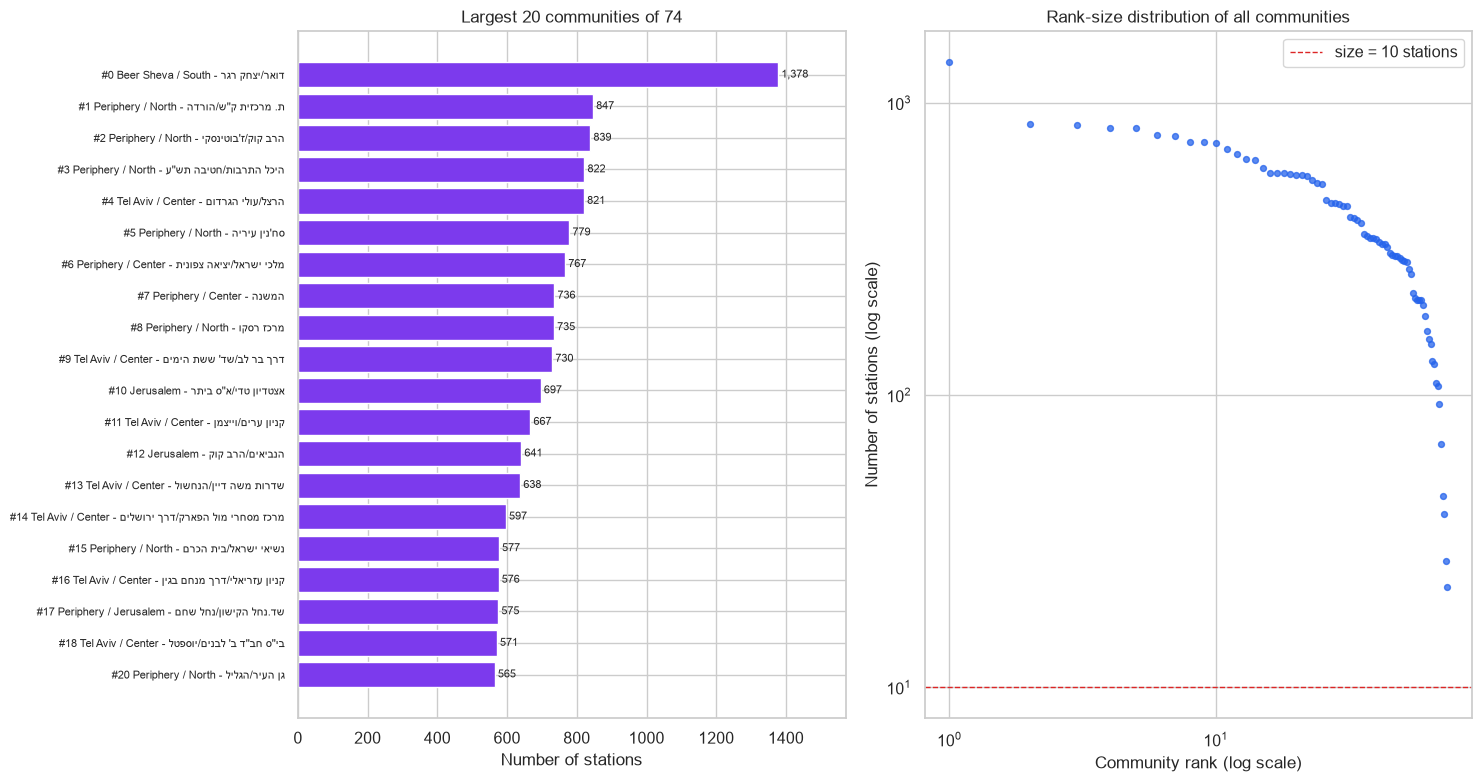

count      74.000000
mean      408.608108
std       249.675725
min        22.000000
25%       217.250000
50%       348.000000
75%       569.500000
max      1378.000000


In [32]:
# --- figures/community_size_distribution.png -------------------------------
top = summary_df.head(TOP_N).iloc[::-1]
top_labels = [f'#{int(cid)} {lab} - {hub}' for cid, lab, hub
              in zip(top['community_id'], top['label'], top['hub_stop_name'])]

sizes_sorted = summary_df['size'].to_numpy()
ranks = np.arange(1, len(sizes_sorted) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

bars = axes[0].barh(range(len(top)), top['size'].to_numpy(), color='#7c3aed')
axes[0].set_yticks(range(len(top)))
axes[0].set_yticklabels(top_labels, fontsize=8)
for bar, val in zip(bars, top['size'].to_numpy()):
    axes[0].text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                 f' {int(val):,}', va='center', fontsize=8)
axes[0].set_xlabel('Number of stations')
axes[0].set_title(f'Largest {len(top)} communities of {num_communities:,}')
axes[0].margins(x=0.14)

axes[1].scatter(ranks, sizes_sorted, s=18, color='#2563eb', alpha=0.75)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].axhline(10, color='#dc2626', linestyle='--', linewidth=1, label='size = 10 stations')
axes[1].set_xlabel('Community rank (log scale)')
axes[1].set_ylabel('Number of stations (log scale)')
axes[1].set_title('Rank-size distribution of all communities')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'community_size_distribution.png', dpi=FIG_DPI)
plt.show()

print(summary_df['size'].describe().to_string())


## 15. Map the strongest boundary stations

We take the top 100 boundary stations with coordinates and plot them over a faint network background. Marker size and color both encode the number of distinct communities touched. This locates the junctions that connect several service clusters and gives us a concrete shortlist for later disruption tests.

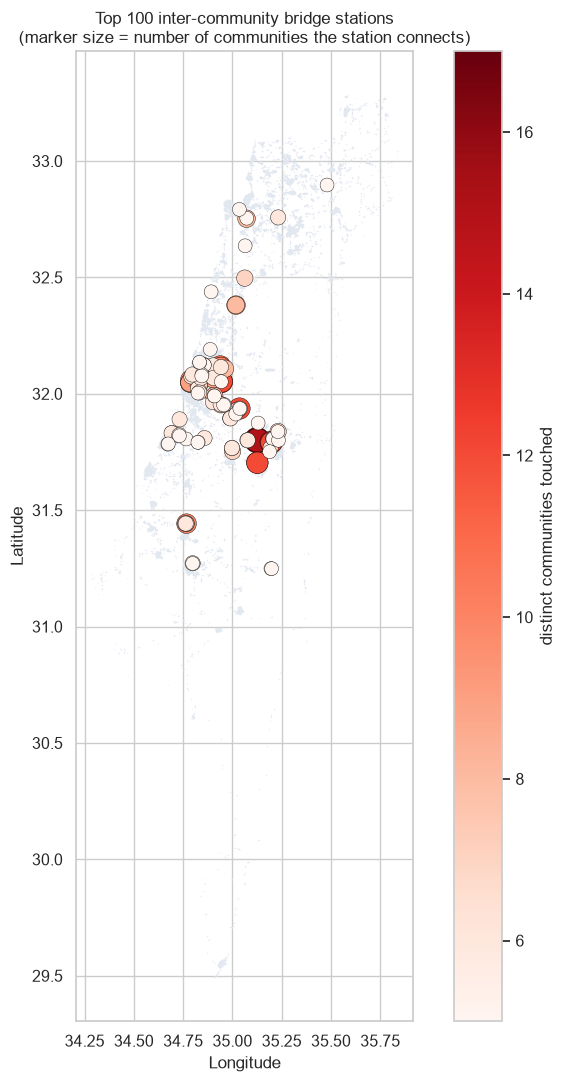

In [33]:
# --- figures/inter_community_bridges_map.png -------------------------------
top_bridges = bridges_df.dropna(subset=['lat', 'lon']).head(100)

fig, ax = plt.subplots(figsize=(8.5, 11))
bg = [n for n in G.nodes() if has_coords(n)]
ax.scatter([G.nodes[n]['lon'] for n in bg], [G.nodes[n]['lat'] for n in bg],
           s=1, color='#e2e8f0', alpha=0.5, linewidths=0)
sc = ax.scatter(top_bridges['lon'], top_bridges['lat'],
                s=top_bridges['connected_communities'] * 20,
                c=top_bridges['connected_communities'], cmap='Reds',
                edgecolors='black', linewidths=0.3, zorder=5)
plt.colorbar(sc, ax=ax, label='distinct communities touched')
ax.set_aspect(1 / np.cos(np.deg2rad(float(np.mean(plot_lats)))))
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Top {len(top_bridges)} inter-community bridge stations\n'
             '(marker size = number of communities the station connects)')
plt.tight_layout()
plt.savefig(FIGURES / 'inter_community_bridges_map.png', dpi=FIG_DPI)
plt.show()


## 16. Save the run configuration with the results

We gather the graph scope, Louvain backend, seed, resolution, partition quality, size statistics, boundary shares, sensitivity ranges, and label-propagation comparison in one dictionary. We write it as JSON and as a one-row CSV. Saving the settings next to the measurements is essential here because the count only has meaning for a particular backend, graph, seed, weighting, and resolution.

In [34]:
# --- community_detection_summary.json --------------------------------------
summary = {
    'louvain_backend': LOUVAIN_BACKEND,
    'louvain_seed': LOUVAIN_SEED,
    'louvain_resolution': LOUVAIN_RESOLUTION,
    'weighted': True,
    'graph_nodes': G.number_of_nodes(),
    'graph_edges': G.number_of_edges(),
    'connected_components': len(components),
    'analysed_nodes': Gc.number_of_nodes(),
    'analysed_edges': Gc.number_of_edges(),
    'num_communities': num_communities,
    'modularity': round(modularity, 4),
    'largest_community_size': int(community_sizes.iloc[0]),
    'largest_community_share': round(float(community_sizes.iloc[0]) / Gc.number_of_nodes(), 4),
    'median_community_size': float(community_sizes.median()),
    'communities_under_10_stations': int((community_sizes < 10).sum()),
    'cross_community_edges': int(cross_edges),
    'cross_community_edge_share': round(cross_edges / Gc.number_of_edges(), 4),
    'cross_community_weight_share': round(cross_weight / component_weight, 4),
    'inter_community_stations': int(len(bridges_df)),
    'inter_community_station_share': round(len(bridges_df) / Gc.number_of_nodes(), 4),
    'max_communities_touched_by_one_station':
        int(bridges_df['connected_communities'].max()) if len(bridges_df) else 0,
    'seed_sweep_seeds': list(SEED_SWEEP),
    'seed_sweep_min_communities': int(seed_runs['num_communities'].min()),
    'seed_sweep_max_communities': int(seed_runs['num_communities'].max()),
    'seed_sweep_min_modularity': float(seed_runs['modularity'].min()),
    'seed_sweep_max_modularity': float(seed_runs['modularity'].max()),
    'seed_sweep_min_ari_vs_reference': float(seed_runs['ari_vs_reference'].min()),
    'label_propagation_communities': int(len(set(partition_lp.values()))) if partition_lp else None,
    'label_propagation_modularity': round(modularity_lp, 4) if modularity_lp is not None else None,
    'label_propagation_ari_vs_louvain': round(ari_lp, 4) if ari_lp is not None else None,
}

with open(STAGE / 'community_detection_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
flat = {k: (json.dumps(v) if isinstance(v, list) else v) for k, v in summary.items()}
pd.DataFrame([flat]).to_csv(TABLES / 'community_detection_summary.csv',
                            index=False, encoding='utf-8-sig')

print('saved:', STAGE / 'community_detection_summary.json')
for p in sorted(TABLES.iterdir()) + sorted(FIGURES.iterdir()):
    print(f'  {p.relative_to(STAGE)}  ({p.stat().st_size / 1024:,.0f} KB)')
pd.DataFrame({'metric': list(summary.keys()), 'value': [str(v) for v in summary.values()]})


saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/08_community_detection/community_detection_summary.json
  tables/community_assignments.csv  (2,423 KB)
  tables/community_detection_summary.csv  (1 KB)
  tables/community_summary.csv  (11 KB)
  tables/inter_community_bridges.csv  (385 KB)
  tables/louvain_stability.csv  (1 KB)
  figures/community_map_louvain.png  (239 KB)
  figures/community_size_distribution.png  (163 KB)
  figures/inter_community_bridges_map.png  (170 KB)
  figures/louvain_stability.png  (131 KB)


,metric,value
0,louvain_backend,networkx
1,louvain_seed,42
2,louvain_resolution,1.0
3,weighted,True
4,graph_nodes,30463
5,graph_edges,51772
6,connected_components,12
7,analysed_nodes,30237
8,analysed_edges,51523
9,num_communities,74


## Conclusions

Our current saved NetworkX run uses seed 42 and resolution 1.0. It gives 74 communities on the 30,237-station largest component with modularity `Q = 0.9436`. We read that as strong separation in this weighted service graph, but we do not treat 74 as an intrinsic network constant.

1. **Seed changes the granularity without changing the objective much.** Across the six seeds, the count ranges from 73 to 83 while modularity stays between 0.9436 and 0.9440. ARI against the reference ranges from 0.7828 to 1.0. The broad structure is similar, but the lowest ARI is far enough from 1 that we should not call every station assignment stable.

2. **Resolution has the largest effect on count.** At the tested settings the count goes from 54 at `gamma = 0.5` to 117 at `gamma = 2.0`. That is expected: resolution explicitly controls whether Louvain prefers larger or smaller groups. The modularity numbers across those rows are not directly comparable because `gamma` changes the objective itself.

3. **Graph scope matters in a simple, visible way.** The full graph has 12 connected components, and 226 stations sit outside the largest one. Running on the full graph would introduce at least 11 additional disconnected groups. We use the largest component so those forced islands do not dominate the interpretation, and we retain the excluded stations as `-1` in the export.

4. **The size distribution is uneven, but there is no tiny-group tail in this run.** Community sizes range from 22 to 1,378 stations, with a median of 348, and none is below ten stations. The map shows mostly geographic patches, which is the sanity check we care about more than the raw count.

5. **Only a small share of scheduled service crosses the detected boundaries.** Boundary stations make up 11.47% of the analyzed component; 7.21% of edges and 3.23% of total edge weight cross communities. The most connected boundary station touches 17 other communities. These stations are useful candidates for resilience testing, but they are not automatically articulation points.

6. **Label propagation does not confirm the Louvain granularity.** It produces 8,035 communities, modularity 0.5469, and ARI 0.0192 against Louvain. That large disagreement tells us the method and the use of weights matter a lot. We can talk about the weighted Louvain structure under the recorded settings, but we should not claim that all community algorithms recover the same partition.

The remaining limitations come from the graph itself: edge weights are scheduled trip records rather than passenger counts, nearby stops are separate unless a trip joins them, and the result comes from one GTFS snapshot. A different backend or refreshed graph should be treated as a new run and described with its own seed, resolution, modularity, and stability table.